# Supervised spillover metrics

The `supervised` (`sp`) module provides metrics to assess how well the single cell profiles in the spatial transcriptomics dataset correlate with a reference scRNA-seq dataset. To compute these metrics, we load both datasets and transfer labels from the reference to the query dataset.

In [6]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd

import segtraq as st

# Define color palette and groups for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Load dataset and transfer labels
First, we load a spatial transcriptomics dataset as well as an annotated single-cell RNAseq dataset. We then use the `run_label_transfer()` function to transfer cell type labels from the scRNAseq data onto our spatial transcriptomics dataset. We can then plot our cell types spatially.

In [2]:
# Load spatial transcriptomics dataset
st_data_path = Path("/g/huber/users/lazic/src/SegTraQ/tests/data/xenium_sdata.zarr")
sdata_10x_xenium = sd.read_zarr(st_data_path)

# Load scRNA-seq dataset
scRNAseq_data_path = Path("/g/huber/users/lazic/src/SegTraQ/tests/data/scRNAseq_ref.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


In [3]:
st.run_label_transfer(sdata_10x_xenium, adata_ref, celltype_key="celltype_major", inplace=True)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:137: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_555/4039217447.py:1: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.
  st.run_label_transfer(sdata_10x_xenium, adata_ref, celltype_key="celltype_major", inplace=True)


Transferred cell-type labels are saved in the AnnData object at `adata.obs['transferred_celltype']` (one label per cell). The dominant cell type in the dataset is T cells (n=523).

Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (`NaN`) with "Unknown" before plotting.

In [4]:
# Replace NaN with Unknown
s = sdata_10x_xenium.tables["table"].obs["transferred_celltype"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

labels = sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

/tmp/ipykernel_555/1845241959.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self

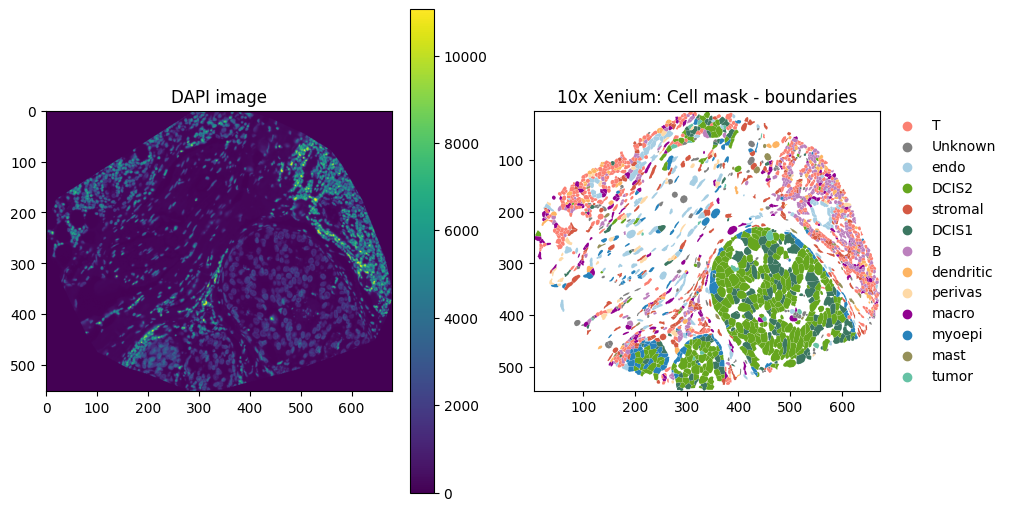

In [7]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
sdata_10x_xenium.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot - Cell boundaries
sdata_10x_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_10x_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata_10x_xenium.pl.render_shapes(
    "cell_boundaries", color="transferred_celltype_plot", palette=cols, groups=labels
).pl.show(ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global")

Before we continue, we extract the `anndata` object from our `spatialdata` object, and perform both normalization and a log-transform on the expression matrix.

In [8]:
tbl = sdata_10x_xenium.tables["table"]
sc.pp.normalize_total(tbl, target_sum=1e4)
sc.pp.log1p(tbl)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


#### Compute positive and negative markers

Some genes are only expressed by certain cell types. This means that we can compute which genes we do or do not see in specific cell types. We call these positive or negative markers.

Positive and negative markers per cell type are identified by computing, for each gene, the difference between its mean expression within the target cell type and its mean expression across all other cells, then selecting genes above the `q_pos` quantile as positive markers and below the `q_neg` quantile as negative markers. To enforce type specificity, genes that appear in at least a `t · n_celltypes` fraction of the per-type marker lists are removed separately for positives and negatives.

We will only consider genes common to the scRNA-seq and spatial transcriptomics dataset to reduce compute time.

In [11]:
# subsetting our spatial proteomics dataset to only contain genes that also appear in the scRNA-seq data
common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [12]:
# computing the positive and negative markers for each cell type
markers = st.sp.get_ref_markers(adata_ref, cell_type_column="celltype_major", q_pos=0.95, q_neg=0.1, t=0.25)

Let's check our positive markers for B and T cells.

In [16]:
markers["B"]["positive"][:20]

['ACP5',
 'ADAM28',
 'ADAM8',
 'ADGRG5',
 'AIM2',
 'AMFR',
 'ANGPTL6',
 'ANKHD1',
 'ANKRD13A',
 'APOBEC3C',
 'APOBEC3F',
 'APOL3',
 'ATP2B1',
 'BANK1',
 'BCL11A',
 'BCL2',
 'BLK',
 'BLNK',
 'BRAF',
 'BTAF1']

In [17]:
markers["T"]["positive"][25:30]

['CD226', 'CD247', 'CD27', 'CD28', 'CD3D']

The first 20 positive markers in B cells include B-lineage signaling genes (BANK1, BLK, BLNK), supporting gens (BACH2, BCL11A, BCL2), genes upregulated downstream of BCR signaling (APOBEC3C/D/F) and ADAM28 reported in B-cell populations.

Among T cell positive markers, we find well-known T cell lienage markers and co-stimulatory receptors.

#### Find mutually exclusive marker pairs

Our next goal is to find pairs of markers that never occur together (they are "mutually exclusive", i.e. if one marker is seen in a cell, we expect the second marker not to be expressed in the same cell). We identify those pairs of genes on the scRNA-seq dataset.

Mutually exclusive gene pairs are identified by scanning each cell type’s positive markers, keeping genes expressed in >20% of that type but <5% of all other cells and retaining only genes that satisfy this criterion for a single type. It then returns all cross-type combinations of these type-unique genes as (gene1, gene2) pairs.

In [18]:
# computing pairs of mutually exclusive genes
mut_excl_marker_pairs = st.sp.get_mut_excl_markers(
    adata_ref,
    cell_type_column="celltype_major",
    markers=markers,
    pos_threshold=0.2,
    neg_threshold=0.05,
    max_codetect=0.01,
)

In [19]:
mut_excl_marker_pairs[10:20]

[('BLK', 'BMPR1B'),
 ('BLK', 'EREG'),
 ('BLK', 'MUC16'),
 ('BLK', 'PCDH10'),
 ('BLK', 'SCGB1D2'),
 ('CD19', 'BMPR1B'),
 ('CD19', 'EREG'),
 ('CD19', 'MUC16'),
 ('CD19', 'PCDH10'),
 ('CD19', 'SCGB1D2')]

Now that we know which markers should never occur together, we can compute the mutually exclusive co-expression Rate (`MECR`) on our spatial transcriptomics data.

The MECR per gene pair in the spatial transcriptomics dataset can be calculated using the `sp.compute_MECR()` method. The MECR measures how often two genes are co-detected relative to how often either is detected, i.e. `MECR = P(both>0) / P(g1>0 ∪ g2>0)`. An MECR of 0 means that the gene pair never co-occurred, which we would expect for our mutually exclusive markers. Non-zero values indicate that there might be some contamination going on.

In [22]:
# computing the MECR
mecr = st.sp.compute_MECR(sdata_10x_xenium, gene_pairs=mut_excl_marker_pairs)

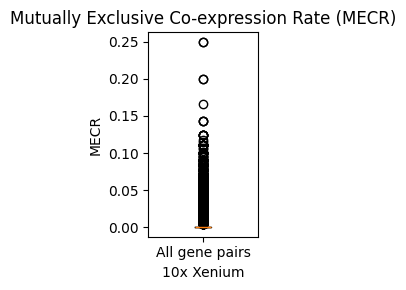

In [29]:
vals = list(mecr.values())

fig, ax = plt.subplots(figsize=(2, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["All gene pairs"])
plt.tight_layout()
plt.show()

In [35]:
vals_nz = [x for x in vals if x > 0]  # non zero
print(f"{100 * (len(vals_nz) / len(vals)):.2f}% of gene pairs that should be mutually exclusive have a non-zero MECR.")
print(f"Median MECR = {np.median(vals_nz)}, variance = {np.var(vals_nz)}")

13.45% of gene pairs that should be mutually exclusive have a non-zero MECR.
Median MECR = 0.025, variance = 0.0004445663483411204


Over all gene pairs, the median MECR is zero, however 13% of the gene pairs found to be mutually exclusive in the reference scRNA-seq dataset have non-zero MECR with a median of 0.025.

#### Evaluate positive and negative marker purity

From our MECR calculations, we know that there are some genes which co-occur when they shouldn't, hinting at some form of contamination. A next logical step would be to identify the cells where this is the case. To do this, we can calculate the marker purity for each cell.

Positive and negative marker purity in the spatial transcriptomics datasets can be computed via `sp.calculate_marker_purity()`. It evaluates, for each cell, how well its expected positive markers are among the cell’s top-expressed genes and how well the negative markers are not among those top genes, using a quantile/rank threshold based on the size of each marker list. From this it computes precision, recall, and F1 for both marker sets and combines them into a single “purity” score that rewards strong positive signal and penalizes negative signal. The output is a per-cell table of these metrics alongside the annotated cell type.

In [39]:
purity_df = st.sp.calculate_marker_purity(sdata_10x_xenium, celltype_column="transferred_celltype", markers=markers)
purity_df.head()

,positive_precision,positive_recall,positive_F1,negative_precision,negative_recall,negative_F1,F1_purity
cell_id,,,,,,,
bfdldgcn-1,0.145455,0.046512,0.070485,0.109091,0.011788,0.021277,0.131499
bfdlebgn-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
bfdlfpan-1,0.000000,0.000000,0.000000,0.166667,0.001965,0.003883,0.000000
bfdlgpib-1,0.148148,0.023256,0.040201,0.148148,0.007859,0.014925,0.077249
bfdljaab-1,0.230769,0.034884,0.060606,0.153846,0.007859,0.014953,0.114187


In [40]:
# add purity scores to AnnData observations
tbl.obs = tbl.obs.merge(
    purity_df.reset_index(),
    how="left",
    left_on="cell_id",
    right_on="cell_id",
)

/tmp/ipykernel_555/1931357063.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby("transferred_celltype_plot")["F1_purity"].median().sort_values(ascending=False).index


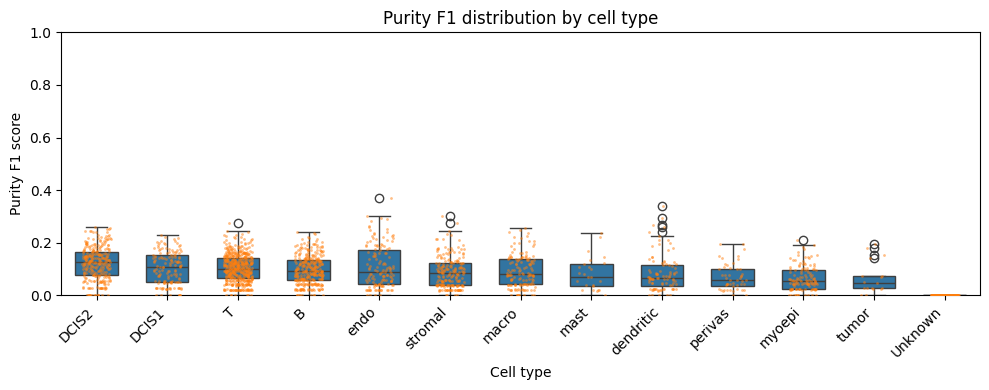

In [41]:
# plotting the distribution of the purity F1 score per cell type
df = tbl.obs[["transferred_celltype_plot", "F1_purity"]].dropna()

order = df.groupby("transferred_celltype_plot")["F1_purity"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="transferred_celltype_plot", y="F1_purity", order=order, width=0.6)
sns.stripplot(data=df, x="transferred_celltype_plot", y="F1_purity", order=order, alpha=0.5, size=2, jitter=0.2)

plt.ylim(0, 1)
plt.xlabel("Cell type")
plt.ylabel("Purity F1 score")
plt.title("Purity F1 distribution by cell type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [42]:
# getting the median F1 purity score per cell type
df.groupby("transferred_celltype_plot")["F1_purity"].median()

/tmp/ipykernel_555/3477823193.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("transferred_celltype_plot")["F1_purity"].median()


transferred_celltype_plot
B            0.091743
DCIS1        0.109256
DCIS2        0.125904
T            0.101747
dendritic    0.066127
endo         0.089415
macro        0.079807
mast         0.070758
myoepi       0.055468
perivas      0.057410
stromal      0.083164
tumor        0.048480
Unknown      0.000000
Name: F1_purity, dtype: float64

From the plot and the median values, we can see that the cell type "tumor" yields the lowest purity F1 score, while DCIS2 has the highest one. 

#### Neigbhorhood contamination

Let's check which cell types are responsible for this contamination. Use the `sp.calculate_contamination()` function to quantify directional “leakage” between cell types in spatial data: for each `ct` cell, it uses a spatial neighbors graph (computed with `squidpy`) to measure what share of ct-specific positive-marker signal appears inside neighboring `ct2` cells, then averages these fractions into a ct→ct2 matrix. 

Higher entries suggest spillover rather than true biology.

In [43]:
k_df, cont_df_diag, cont_df = st.sp.calculate_contamination(
    sdata_10x_xenium,
    markers=markers,
    celltype_column="transferred_celltype",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

Let's visualize the incoming contamination for each cell type.

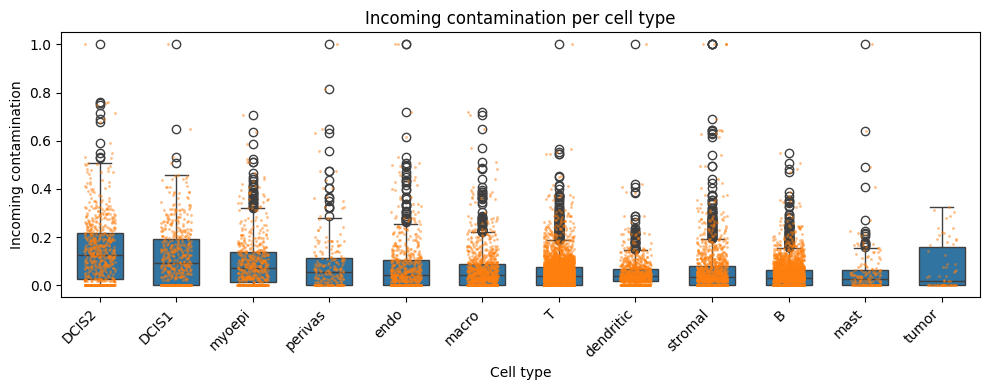

In [44]:
cont_df = cont_df[["neighbor_type", "ratio"]].dropna()

order = cont_df.groupby("neighbor_type")["ratio"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=cont_df, x="neighbor_type", y="ratio", order=order, width=0.6)
sns.stripplot(data=cont_df, x="neighbor_type", y="ratio", order=order, alpha=0.5, size=2, jitter=0.2)

# plt.ylim(0, 12)
plt.xlabel("Cell type")
plt.ylabel("Incoming contamination")
plt.title("Incoming contamination per cell type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

It is not good to look at this in a boxplot because dominant neighbors will dominate the results. DCIS2 incoming signal will mostly be dominated by DCIS1 outgoing signal and since there is a lot of DCIS1 ...better to look at heatmap where this is scaled by the number of interactions.

/tmp/ipykernel_555/2443333179.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = cont_df.groupby("transferred_celltype_plot")["transcript_count"].median().sort_values(ascending=False).index


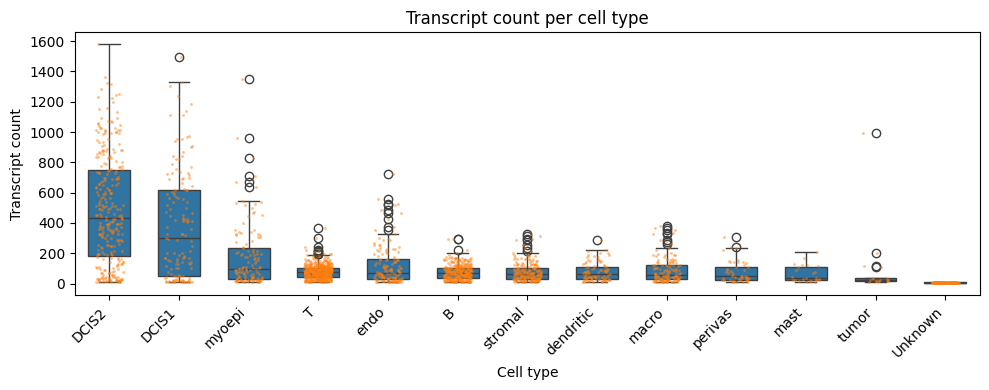

In [46]:
cont_df = tbl.obs[["transferred_celltype_plot", "transcript_count"]].dropna()

order = cont_df.groupby("transferred_celltype_plot")["transcript_count"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=cont_df, x="transferred_celltype_plot", y="transcript_count", order=order, width=0.6)
sns.stripplot(
    data=cont_df, x="transferred_celltype_plot", y="transcript_count", order=order, alpha=0.5, size=2, jitter=0.2
)

# plt.ylim(0, 12)
plt.xlabel("Cell type")
plt.ylabel("Transcript count")
plt.title("Transcript count per cell type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

I am not 100% sure how to interpret the heatmap below...can one compare between cell types, e.g. DCIS2 mostly contaminate into perivas and DCIS1 ... would have expected that they contaminated into myoepi, because they most often neighbor those...maybe don't divide by count of interactions??? - because then contamination from 1 interaction has the same weight as multiple interactions

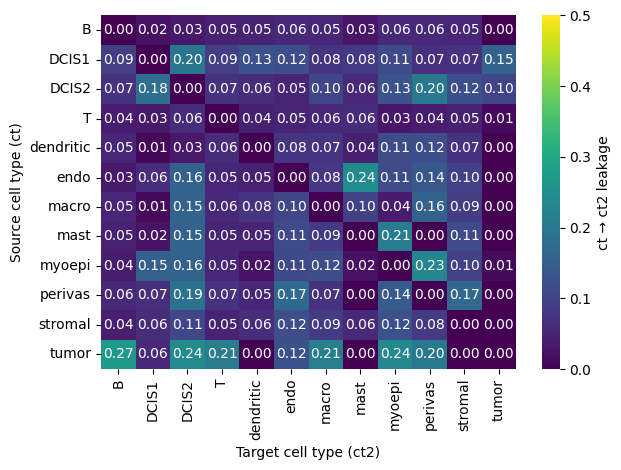

In [45]:
ax = sns.heatmap(
    cont_df_diag, vmin=0, vmax=0.5, cmap="viridis", annot=True, fmt=".2f", cbar_kws={"label": "ct → ct2 leakage"}
)
ax.set_xlabel("Target cell type (ct2)")
ax.set_ylabel("Source cell type (ct)")
plt.tight_layout()

Contamination and purity for individual cell types do not seem to correlate. Strong correlation between purity and contamination isn’t guaranteed, since the two readouts measure different things:

Purity is an intracellular score (does each cell’s own profile match its marker set?).

Contamination is a directional, neighborhood metric (what fraction of a type-specific signature from cells of type ct shows up in nearby ct2 cells). Because it depends on spatial adjacency and a graph, it can vary independently of per-cell purity.

A cell (e.g. of type DCIS1) can have a pure expression, but still have a high contamination of neighboring cell positive markers with respect to the expression of those markers in this respective neighborhood. 